In [ ]:
# >>> repo path setup (auto-added during reorg; keeps this notebook runnable from notebooks/) <<<
import os, sys
_p = os.getcwd()
while not os.path.isdir(os.path.join(_p, 'src')) and os.path.dirname(_p) != _p:
    _p = os.path.dirname(_p)
os.chdir(_p)
sys.path.insert(0, os.path.join(_p, 'src'))
# <<< end repo path setup >>>

In [39]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [40]:
import torch
import arviz as az
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap, BoundaryNorm
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
from tqdm import tqdm


from seisfwi.model import AcousticModel, RockPhysicsGassmann
from seisfwi.survey import SeismicData
from seisfwi.utils import plot_misfit, load_log_file
import seisfwi.defaults as defaults

from utils.vae import VanillaVAE
from utils.project_plots import configure_plot_settings, plot_2d
from utils.project_utils import rockphysic_inversion
from utils import RockPhysicsModel

from HMC_FWI_VAE import get_survey

In [41]:
configure_plot_settings()
cmap_range     = {'vp': (1400, 4500)}
cmap_range_co2 = {'vp': (-125,  125)}

In [42]:
nz0 = 260
nx0 = 110
nz_res = 15
nx_res = 179
x_res = (np.arange(nx_res) + nx0) * 5.0
z_res = (np.arange(nz_res) + nz0) * 5.0 

In [43]:
src_id = 1
rec_id = 1
f0 = 30          # 60
noise_flag= ""   #"-noise-30dB"

path = Path(f"/net/vision/scr2/haipeng/FWI-HMC/Runs-Paper/SYN-survey-{src_id}-geophone-{rec_id}-{f0}Hz{noise_flag}")
path

PosixPath('/net/vision/scr2/haipeng/FWI-HMC/Runs-Paper/SYN-survey-1-geophone-1-30Hz')

In [44]:
model_bl, model_ml, survey = get_survey(f0 = f0, src_id=src_id, rec_id=rec_id, vp_ml_file = f'model/vp_ml_nz346_nx401_5m.npy')
model_fwi = AcousticModel.load(path/"Model-FWI.npz")
sa_fwi = np.load(path/"Model-FWI-Sat.npy").reshape(15, 179)

vp_bl = model_bl.get_model('vp')    
vp_ml = model_ml.get_model('vp')
vp_fwi = model_fwi.get_model('vp') - vp_bl
vp_obs = vp_ml - vp_bl

vp_fwi = vp_fwi[nz0:nz0+nz_res, nx0:nx0+nx_res]
vp_obs = vp_obs[nz0:nz0+nz_res, nx0:nx0+nx_res]

x, z = model_bl.x, model_bl.z

### Rock physics inversion

In [45]:
vp_res = np.load("./model/vp_res_nz15_nx179_5m.npy")

# Parameters for rock physics model
rock_physics_params = RockPhysicsModel(vp_res)

# Gassmann fluid substitution
rockphy = RockPhysicsGassmann(**rock_physics_params)

    Brine properties: K = 2.62 GPa, rho = 1013.5368 kg/m3
      CO2 properties: K = 0.03 GPa, rho = 537.8947 kg/m3
  Mineral properties: K = 36.93 GPa, rho = 2645.1000 kg/m3
  Estimated porosity: phi = 0.1412


In [46]:
sa_fwi_inv = rockphysic_inversion(rockphy, vp_fwi, max_iter = 100, verbose=True)

Iteration 0001/100: Loss = 8095.54
Iteration 0011/100: Loss = 3245.46
Iteration 0021/100: Loss = 1023.57
Iteration 0031/100: Loss = 282.05
Iteration 0041/100: Loss = 99.87
Iteration 0051/100: Loss = 52.48
Iteration 0061/100: Loss = 34.36
Iteration 0071/100: Loss = 28.19
Iteration 0081/100: Loss = 26.22
Iteration 0091/100: Loss = 25.37
Iteration 0100/100: Loss = 25.04


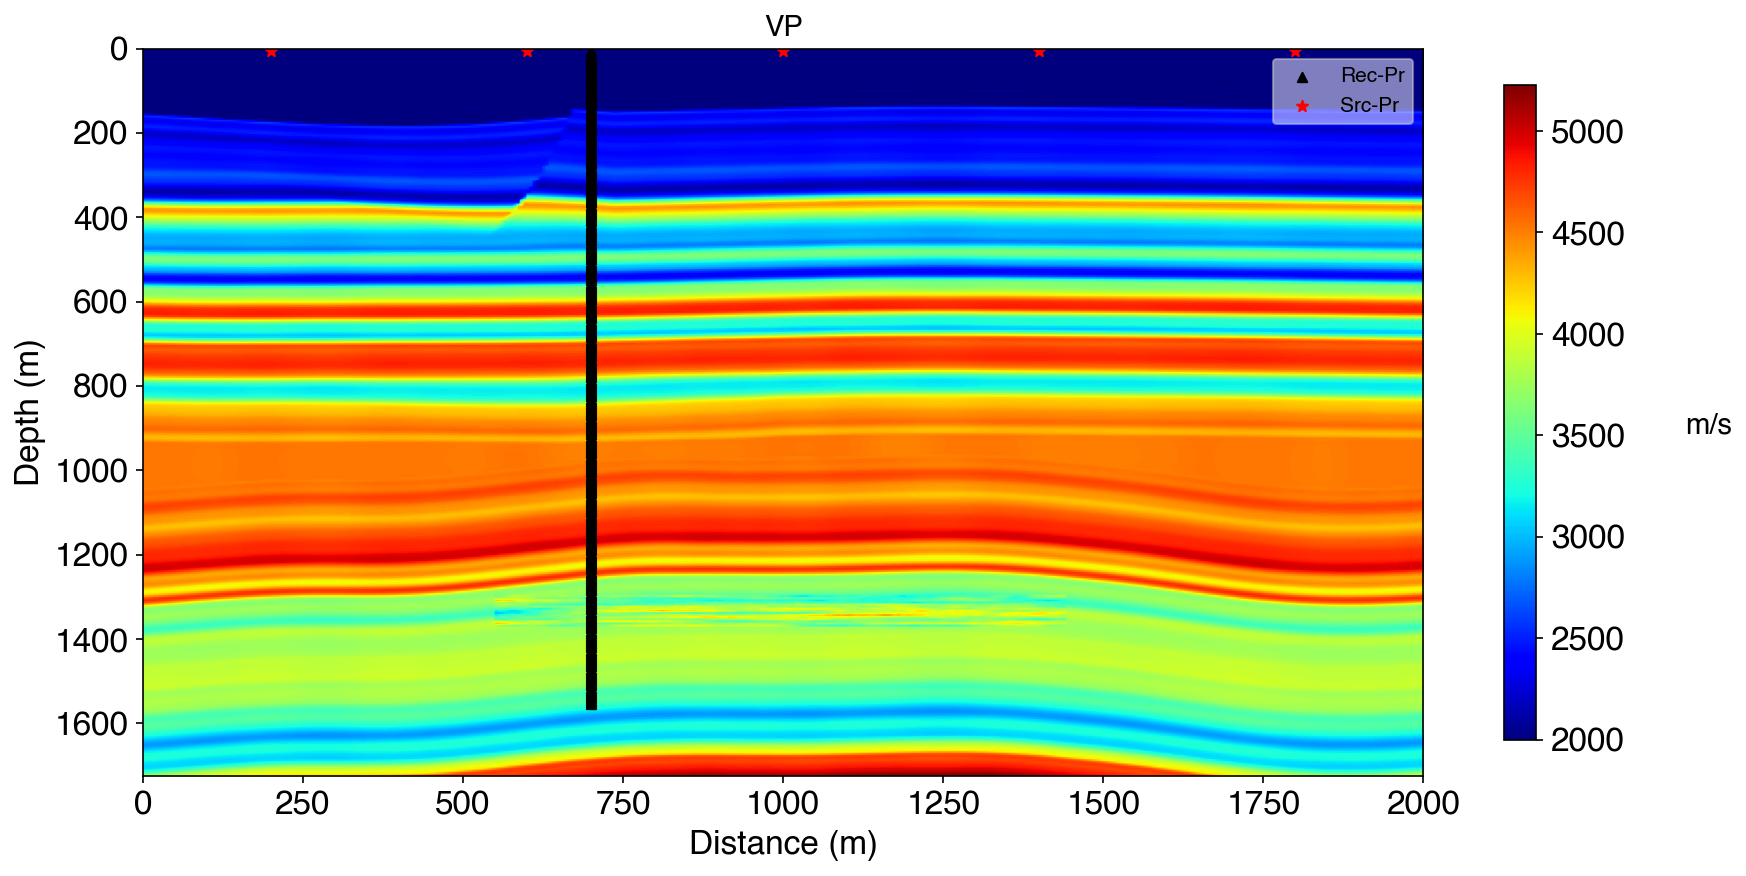

In [47]:
model_bl.plot(survey, cmap='jet', orientation='vertical', figsize=(12, 6))

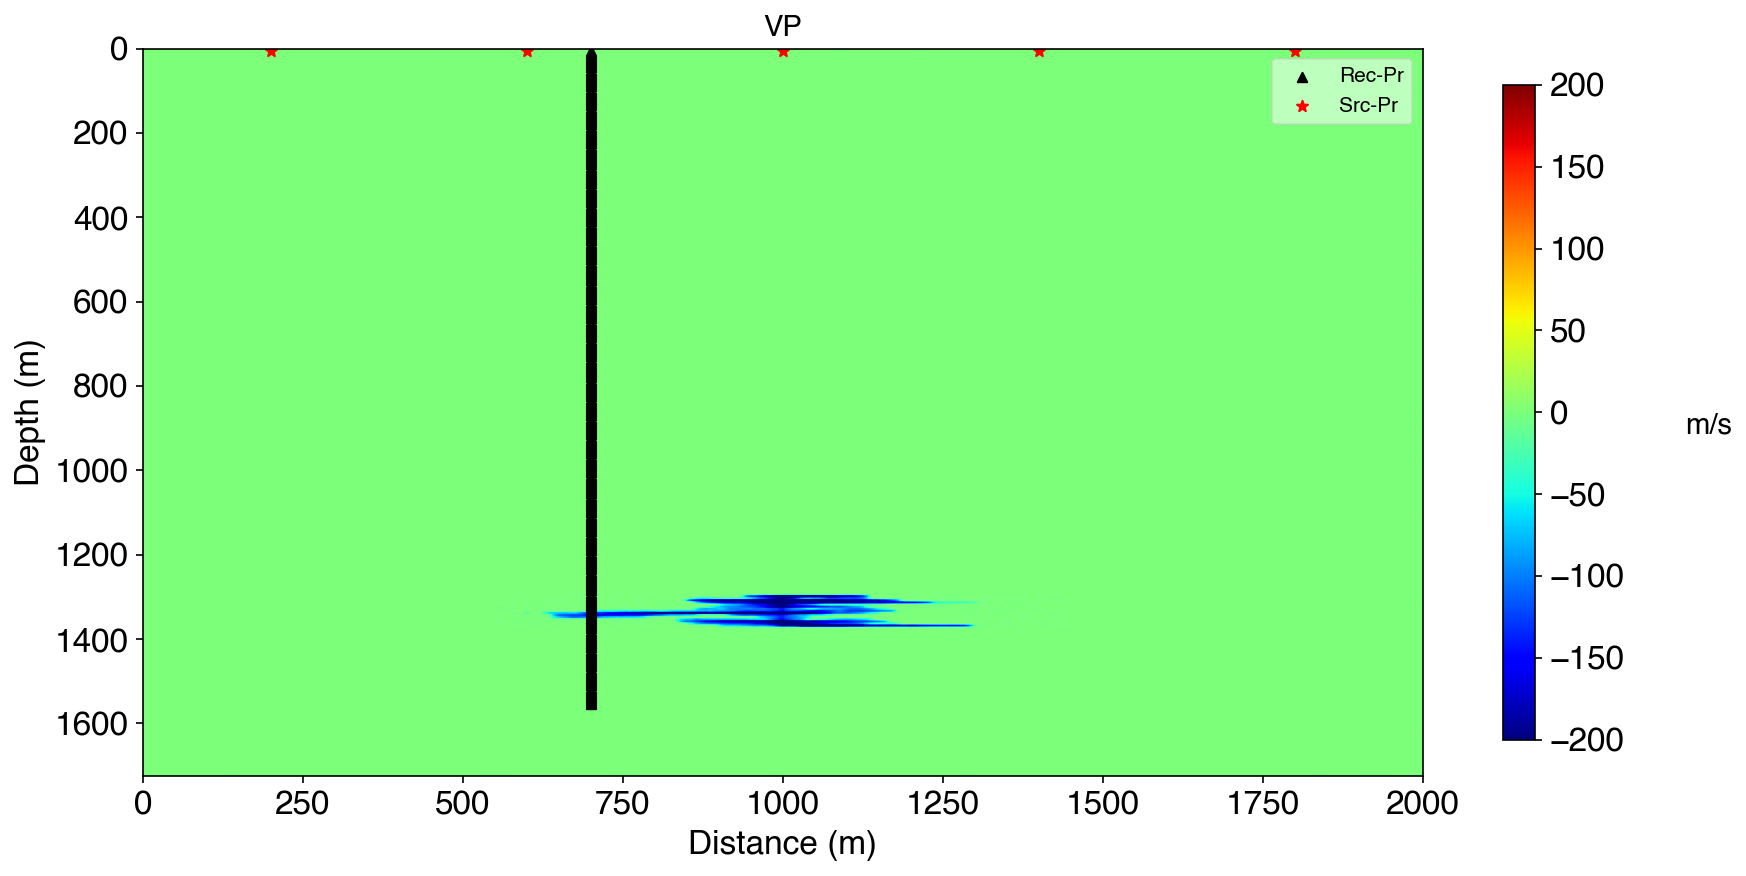

In [48]:
(model_ml - model_bl).plot(survey, cmap='jet', orientation='vertical', figsize=(12, 6), cmap_range = {'vp': (-200, 200)})

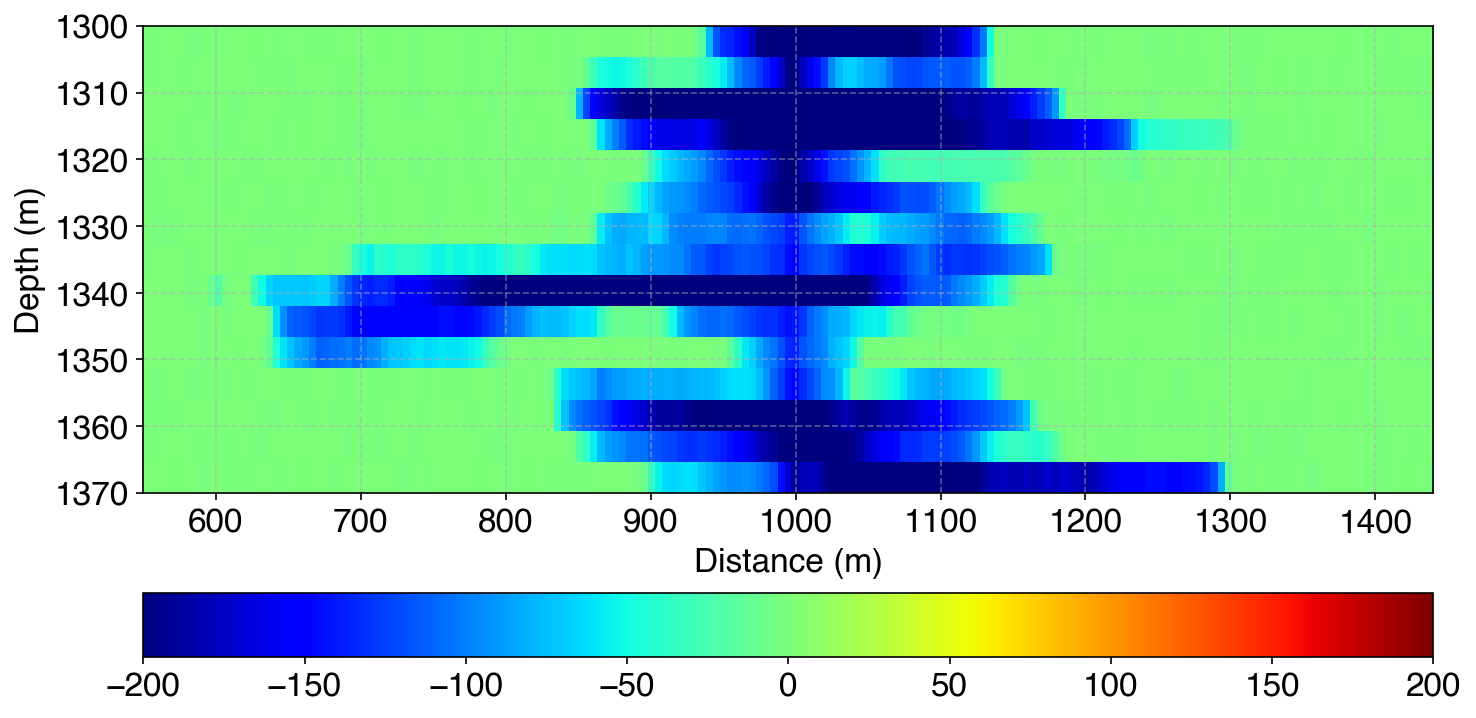

In [49]:
plot_2d(x_res, z_res, vp_obs, vmin=-200, vmax=200, cmap='jet')

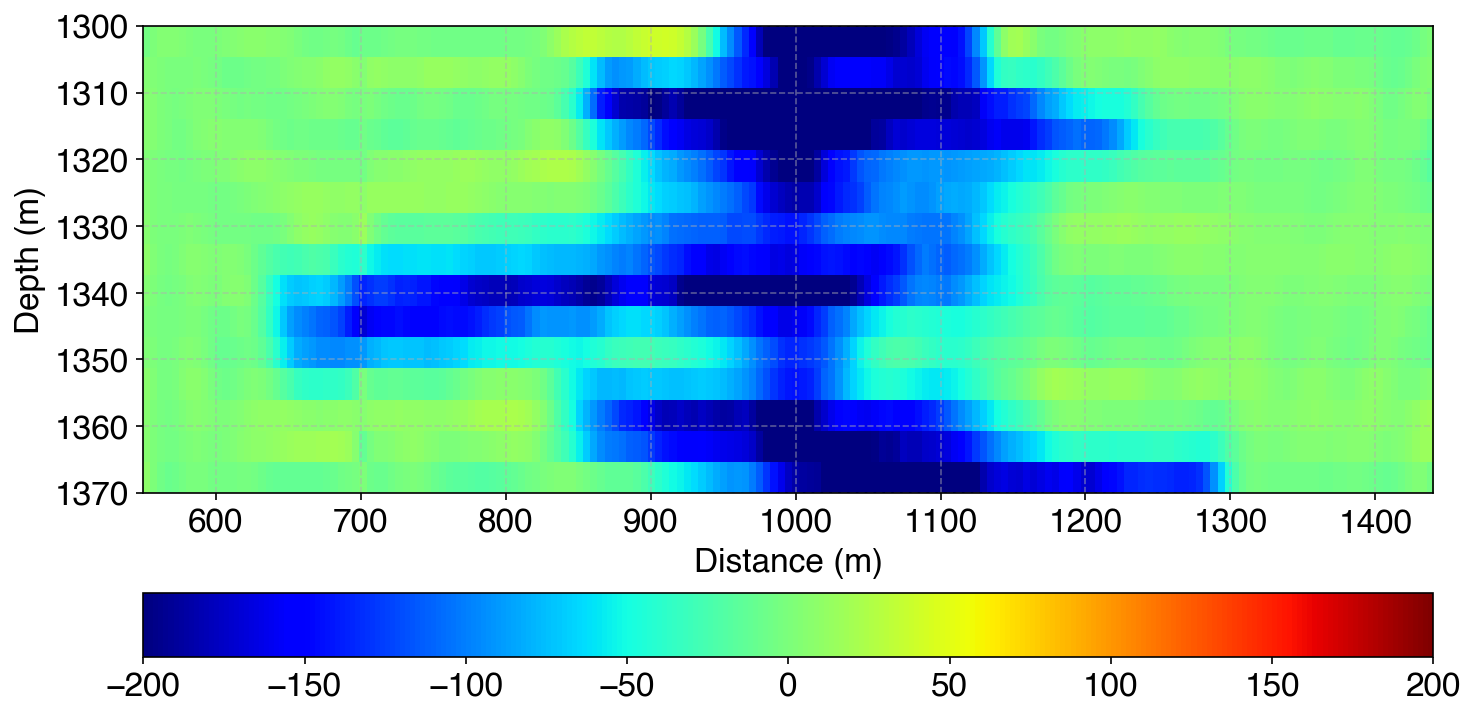

In [50]:
plot_2d(x_res, z_res, vp_fwi, vmin=-200, vmax=200, cmap='jet')

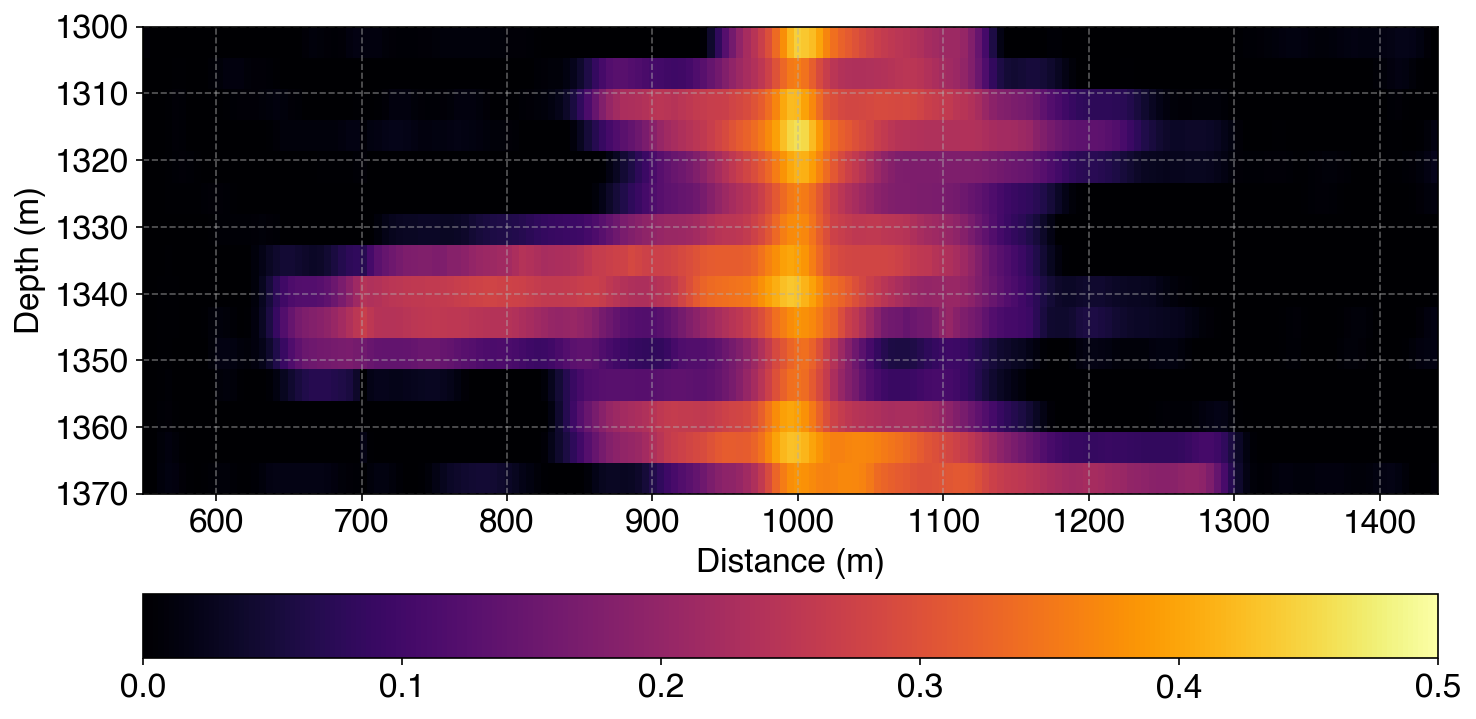

In [51]:
plot_2d(x_res, z_res, sa_fwi_inv, vmin=0, vmax=0.5, cmap='inferno')

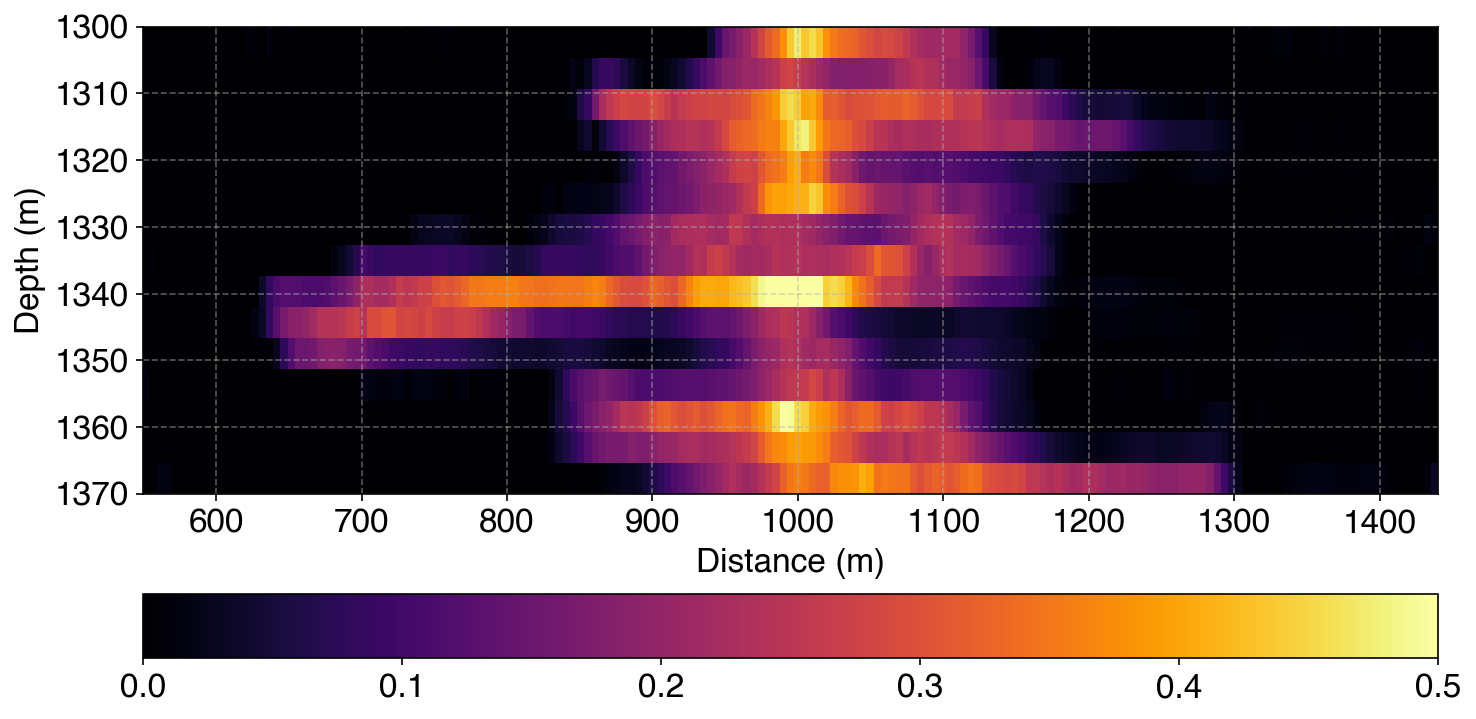

In [52]:
plot_2d(x_res, z_res, sa_fwi, vmin=0, vmax=0.5, cmap='inferno')

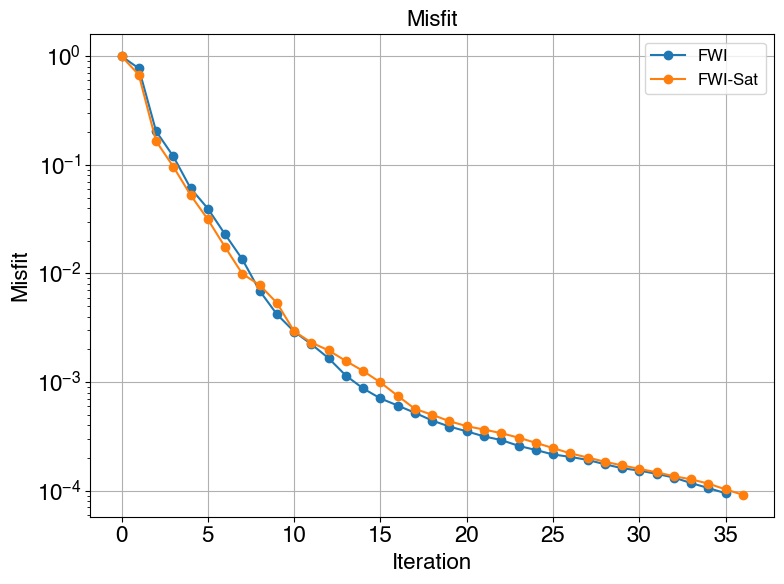

In [53]:
misfit_fd  = load_log_file(path/'FWI.log')
misfit_sat = load_log_file(path/'FWI-Sat.log')

plot_misfit([misfit_fd['fk'].values, misfit_sat['fk'].values], label=['FWI', 'FWI-Sat'], figsize=(8,6))

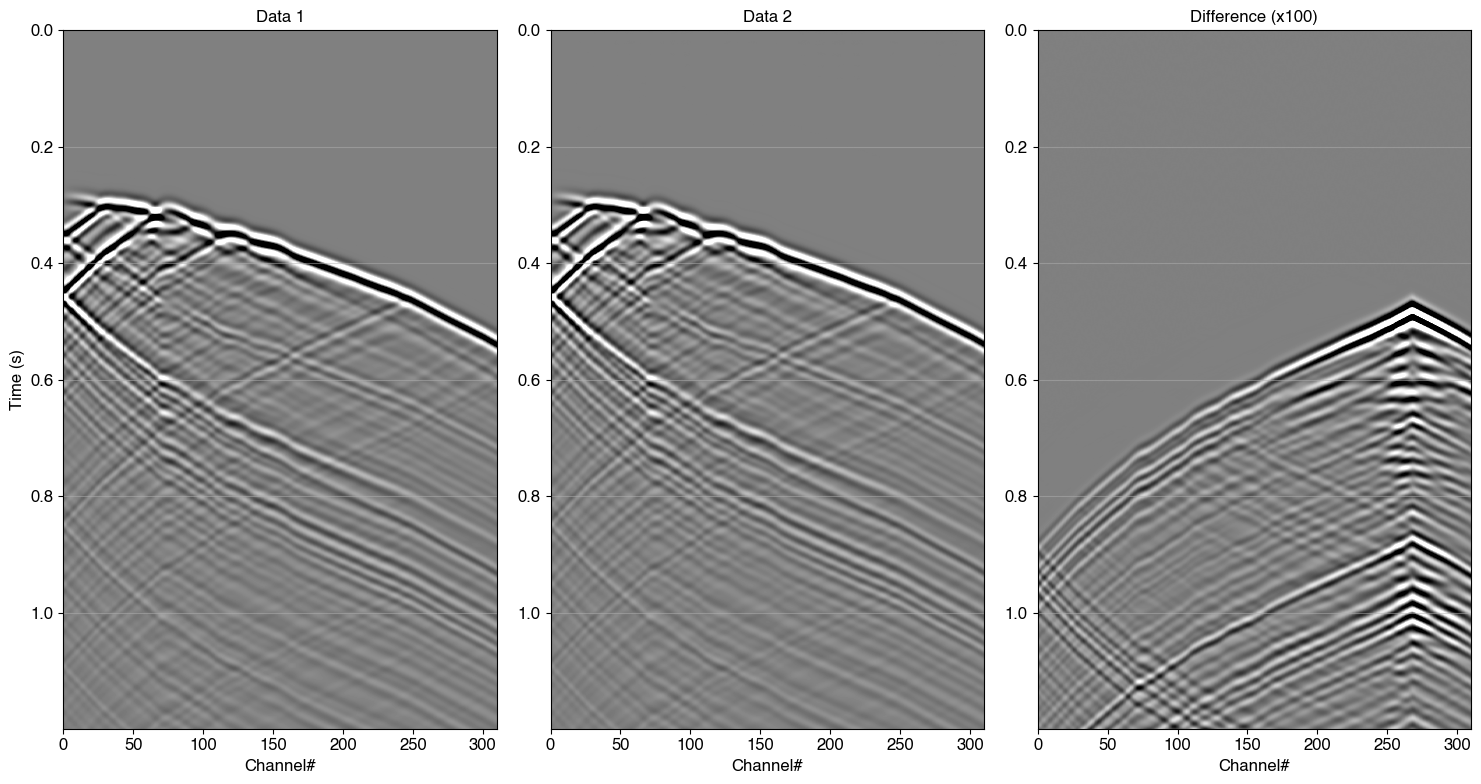

In [54]:
dobs_bl_clean = SeismicData.load(f'{path}/dobs-BL.npz')
dobs_ml_clean = SeismicData.load(f'{path}/dobs-ML.npz')
dobs_ml_clean.plot_compare(dobs_bl_clean, comp=['pr'], ratio=100, pclip=99)

In [79]:
len(x), len(z), dobs_bl_clean.data['pr'].shape

(401, 346, torch.Size([5, 311, 1200]))

### Bayesian FWI 

In [55]:
# HMC parameters
num_samples = 40000
hmc_temp = 0.025

In [56]:
!ls $path/HMC

LogProb-hmc-num-40000-temp-0.025.npy	 Posterior-hmc-num-40000-temp-0.025.nc
Posterior-hmc-num-40000-temp-0.025.json  Prior-hmc-num-40000-temp-0.025.npy


In [57]:
latent_prior        = np.load(       path / f"HMC/Prior-hmc-num-{num_samples}-temp-{hmc_temp}.npy")
log_prob            = np.load(       path / f"HMC/LogProb-hmc-num-{num_samples}-temp-{hmc_temp}.npy")
latent_posterior_az = az.from_netcdf(path / f"HMC/Posterior-hmc-num-{num_samples}-temp-{hmc_temp}.nc")
latent_posterior    = latent_posterior_az.posterior['m'].values[0]

In [58]:
latent_posterior_az

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

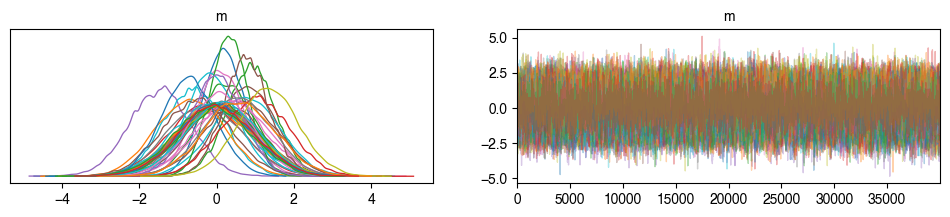

In [59]:
az.plot_trace(latent_posterior_az, var_names=["m"])
None

In [60]:
summary = az.summary(latent_posterior_az, round_to=3)
summary

arviz - WARNING - Shape validation failed: input_shape: (1, 40000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
m[0],0.006,0.992,-1.825,1.919,0.035,0.024,826.185,1596.373,NaN
m[1],0.024,0.976,-1.784,1.873,0.033,0.023,885.054,1977.553,NaN
m[2],0.279,0.761,-1.155,1.704,0.022,0.016,1190.386,2512.708,NaN
m[3],-0.284,0.971,-2.142,1.511,0.037,0.026,678.996,1830.913,NaN
m[4],-1.470,0.802,-2.994,-0.002,0.027,0.019,869.886,2080.723,NaN
...,...,...,...,...,...,...,...,...,...
m[59],0.140,0.925,-1.626,1.851,0.030,0.021,978.000,2273.035,NaN
m[60],0.005,0.972,-1.780,1.852,0.035,0.024,795.644,1655.433,NaN
m[61],0.592,0.920,-1.132,2.322,0.031,0.022,874.864,1920.295,NaN
m[62],-0.107,0.989,-1.927,1.790,0.033,0.023,889.203,1952.014,NaN


In [61]:
sd = summary["sd"].values              # shape (64,)
mcse_sd = summary["mcse_sd"].values    # shape (64,)
ratio = mcse_sd / sd                   # relative MC error
print(f"ratio min/median/max: {ratio.min():.4f}  {np.median(ratio):.4f}  {ratio.max():.4f}")

ratio min/median/max: 0.0161  0.0238  0.0287


### Saturation model

In [62]:
# Load VAE Model
kld_weight = 0.000015
in_channels = 1
latent_dim = 64
device = torch.device(defaults.device)
checkpoint_path = f"/net/vision/scr2/haipeng/FWI-HMC/VAE/vae_latent_dim{latent_dim}_kld_weight{kld_weight}.pth"

# Reload the model
model_vae = VanillaVAE(in_channels=in_channels, latent_dim=latent_dim).to(defaults.device)
model_vae.load_state_dict(torch.load(checkpoint_path, map_location=defaults.device))
model_vae.eval()

def decode_in_batches(model, latent_tensor, batch_size):
    """Decode latent vectors in batches to avoid GPU OOM."""
    decoded = []
    n_samples = latent_tensor.shape[0]

    with torch.no_grad():
        for i in tqdm(range(0, n_samples, batch_size), desc="Decoding batches"):
            batch = latent_tensor[i:i + batch_size]
            decoded_batch = model.decode(batch)
            decoded_batch = F.interpolate(decoded_batch, size=(15, 179), mode='bilinear', align_corners=False)
            decoded.append(decoded_batch.cpu())
            
    decoded = torch.cat(decoded, dim=0)
    # compute mean, std, p10, p50, p90
    p10 = torch.quantile(decoded, 0.1, dim=0).numpy().squeeze()
    p50 = torch.quantile(decoded, 0.5, dim=0).numpy().squeeze()
    p90 = torch.quantile(decoded, 0.9, dim=0).numpy().squeeze()
    mean = torch.mean(decoded, dim=0).numpy().squeeze()
    std = torch.std(decoded, dim=0).numpy().squeeze()
    
    decoded = decoded.numpy().squeeze()

    return decoded, mean, std, p10, p50, p90

In [63]:
# Convert to tensor and move to device
latent_prior_tensor     = torch.as_tensor(latent_prior, dtype=torch.float32, device=device)
latent_posterior_tensor = torch.as_tensor(latent_posterior, dtype=torch.float32, device=device)

# Run batched decoding
sa_prior, sa_prior_mean, sa_prior_std, sa_prior_p10, sa_prior_p50, sa_prior_p90 = decode_in_batches(model_vae, latent_prior_tensor, 512)
sa_post , sa_post_mean,  sa_post_std,  sa_post_p10,  sa_post_p50,  sa_post_p90  = decode_in_batches(model_vae, latent_posterior_tensor, 512)

# Find MAP sample
map_id = np.argmax(log_prob)
sa_map = sa_post[map_id]

Decoding batches: 100%|██████████| 79/79 [00:01<00:00, 47.08it/s]


In [64]:
# Load the true saturation
sa_obs = np.load('model/sa_res_nz15_nx179_5m.npy')

# coordinates for plotting
dx, dz = 5.0, 5.0 
nz_sat, nx_sat = 15, 179
res_x = np.arange(nx_sat) * dx + 110 * dx
res_z = np.arange(nz_sat) * dz + 260 * dz
extent_res = [res_x[0]/1000, res_x[-1]/1000, res_z[-1]-res_z[0], 0]

vp_fwi = vp_fwi[260:260+nz_sat, 110:110+nx_sat]
vp_obs = vp_obs[260:260+nz_sat, 110:110+nx_sat]

In [65]:
# Selected (z, x) positions in km
selected_indices = [
    (1315, 910), (1320, 995), (1325, 1200),
    (1340, 690), (1365, 995), (1360, 1140)
]

/tmp/ipykernel_38673/3078729836.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


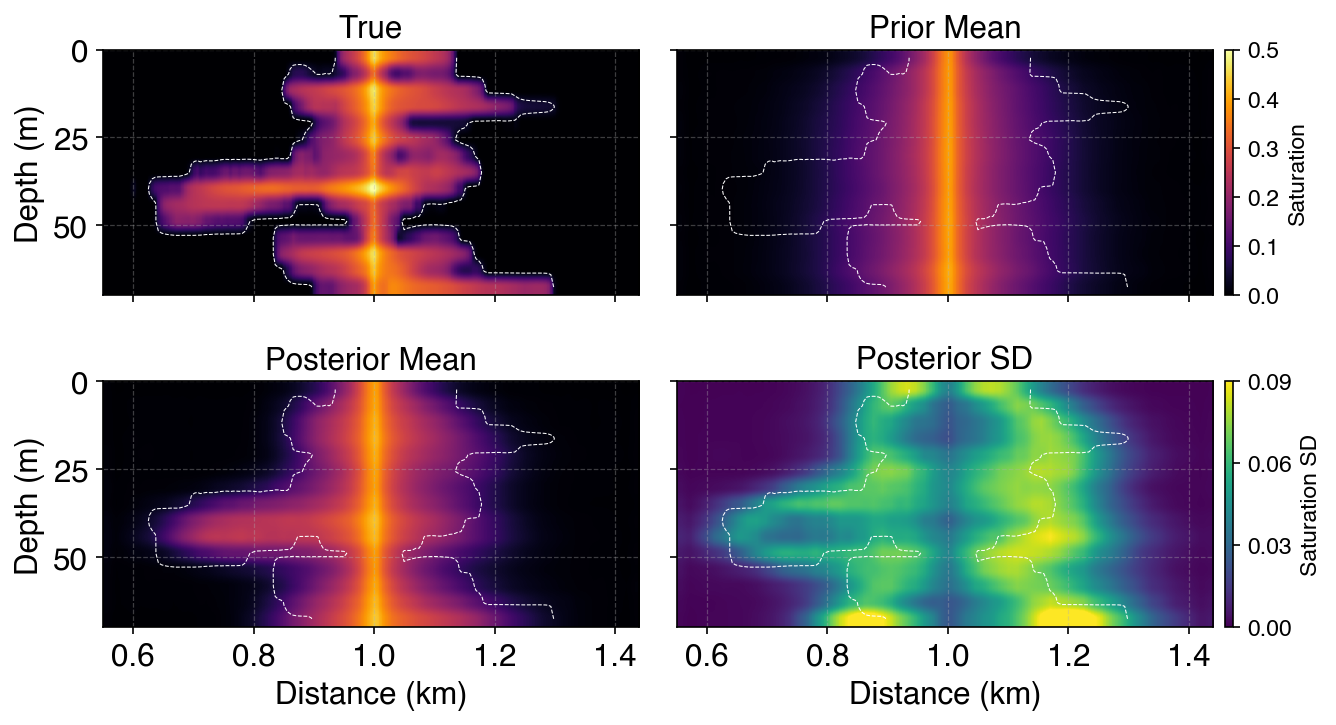

In [66]:
fontsize = 15
plt.rcParams.update({'font.size': fontsize})

# Assemble data and titles
data_plot = [
    sa_obs,                 
    sa_prior_mean,      
    sa_post_mean,      
    sa_post_std,       
]
titles = [
    'True',
    'Prior Mean',
    'Posterior Mean',
    'Posterior SD',
]

extent = [0.0, x[-1]/1000, z[-1]-1300, z[0]-1300]

# Indices of Vp-like panels (share one colorbar/scale) vs sequential panels
idx_vp = [0, 1, 2]  # Vp maps
labels = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)']  # Panel labels

# Layout
ncols, nrows = 2, 2
fig = plt.figure(figsize=(10, 5), dpi=150)
gs = gridspec.GridSpec(nrows, ncols, figure=fig, wspace=0.07, hspace=0.35)

axes = []
im_vp_for_cbar  = None
im_seq_for_cbar = None

for i, data in enumerate(data_plot):
    r, c = divmod(i, ncols)
    ax = fig.add_subplot(gs[r, c], sharex=axes[0] if axes else None, sharey=axes[0] if axes else None)
    axes.append(ax)

    if i in idx_vp:
        im = ax.imshow(data, cmap='inferno', vmin=0, vmax=0.5, aspect='auto', extent=extent_res)
        ax.contour(sa_obs, levels=[0.03], extent=extent_res, colors='w', linewidths=0.5, linestyles='dashed', origin='upper')

        im_vp_for_cbar = im
    else:
        im = ax.imshow(data, cmap='viridis', vmin=0, vmax=0.09, aspect='auto', extent=extent_res)
        im_seq_for_cbar = im
        ax.contour(sa_obs, levels=[0.03], extent=extent_res, colors='w', linewidths=0.5, linestyles='dashed', origin='upper')

    # if i==0:
    #     for idex, (z_, x_) in enumerate(selected_indices):
    #         plt.plot(x_/1000,       z_-1300, 'wo', markersize=6, markeredgecolor='k', markeredgewidth=0.8)
    #         plt.text(x_/1000+0.015, z_-1300+3, f"{idex+1}", color='w', fontsize=12, fontweight='bold')


    ax.set_title(titles[i], fontsize=fontsize)
    # ax.text(0.0, 1.2, labels[i], transform=ax.transAxes, fontsize=fontsize+3, va='top', ha='left', color='black', fontweight='bold')
    ax.grid(linestyle='--', alpha=0.35, linewidth=0.6)
    ax.tick_params(axis='both', which='major', labelsize=fontsize)

    if r < nrows - 1:
        ax.tick_params(labelbottom=False)
    if c > 0:
        ax.tick_params(labelleft=False)

# Set a consistent viewing window (adjust as needed)
# for ax in axes:
    # ax.set_xlim(res_x[0]/1000, res_x[-1]/1000)  # Distance (km)
    # ax.set_ylim(res_z[-1]-res_z[0], 0)  # Depth (km)
    # ax.set_yticks(np.arange(0.80, 0.88, 0.02))

# Common axis labels
for c in range(ncols):
    axes[(nrows-1)*ncols + c].set_xlabel('Distance (km)', fontsize=fontsize)
axes[0].set_ylabel('Depth (m)', fontsize=fontsize)
axes[2].set_ylabel('Depth (m)', fontsize=fontsize)

cbar_sa = fig.colorbar(im_vp_for_cbar,  ax=[axes[i] for i in idx_vp][:-1], fraction=0.035, pad=0.01, aspect=30)
cbar_sa.set_label('Saturation', fontsize=fontsize-4)
cbar_sa.ax.tick_params(labelsize=fontsize-4)
cbar_sa.minorticks_off()

cbar_seq = fig.colorbar(im_seq_for_cbar, ax=[axes[i] for i in [2, 3]],fraction=0.035, pad=0.01, aspect=30)
cbar_seq.set_label('Saturation SD', fontsize=fontsize-4)
cbar_seq.ax.tick_params(labelsize=fontsize-4)
cbar_seq.set_ticks([0, 0.03, 0.06, 0.09])
cbar_seq.minorticks_off()

plt.tight_layout()
plt.savefig(f"figures_slides/FWI-HMC-Result-model-num-{num_samples}-temp-{hmc_temp}-f0-{f0}Hz.png", dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_38673/3415237510.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


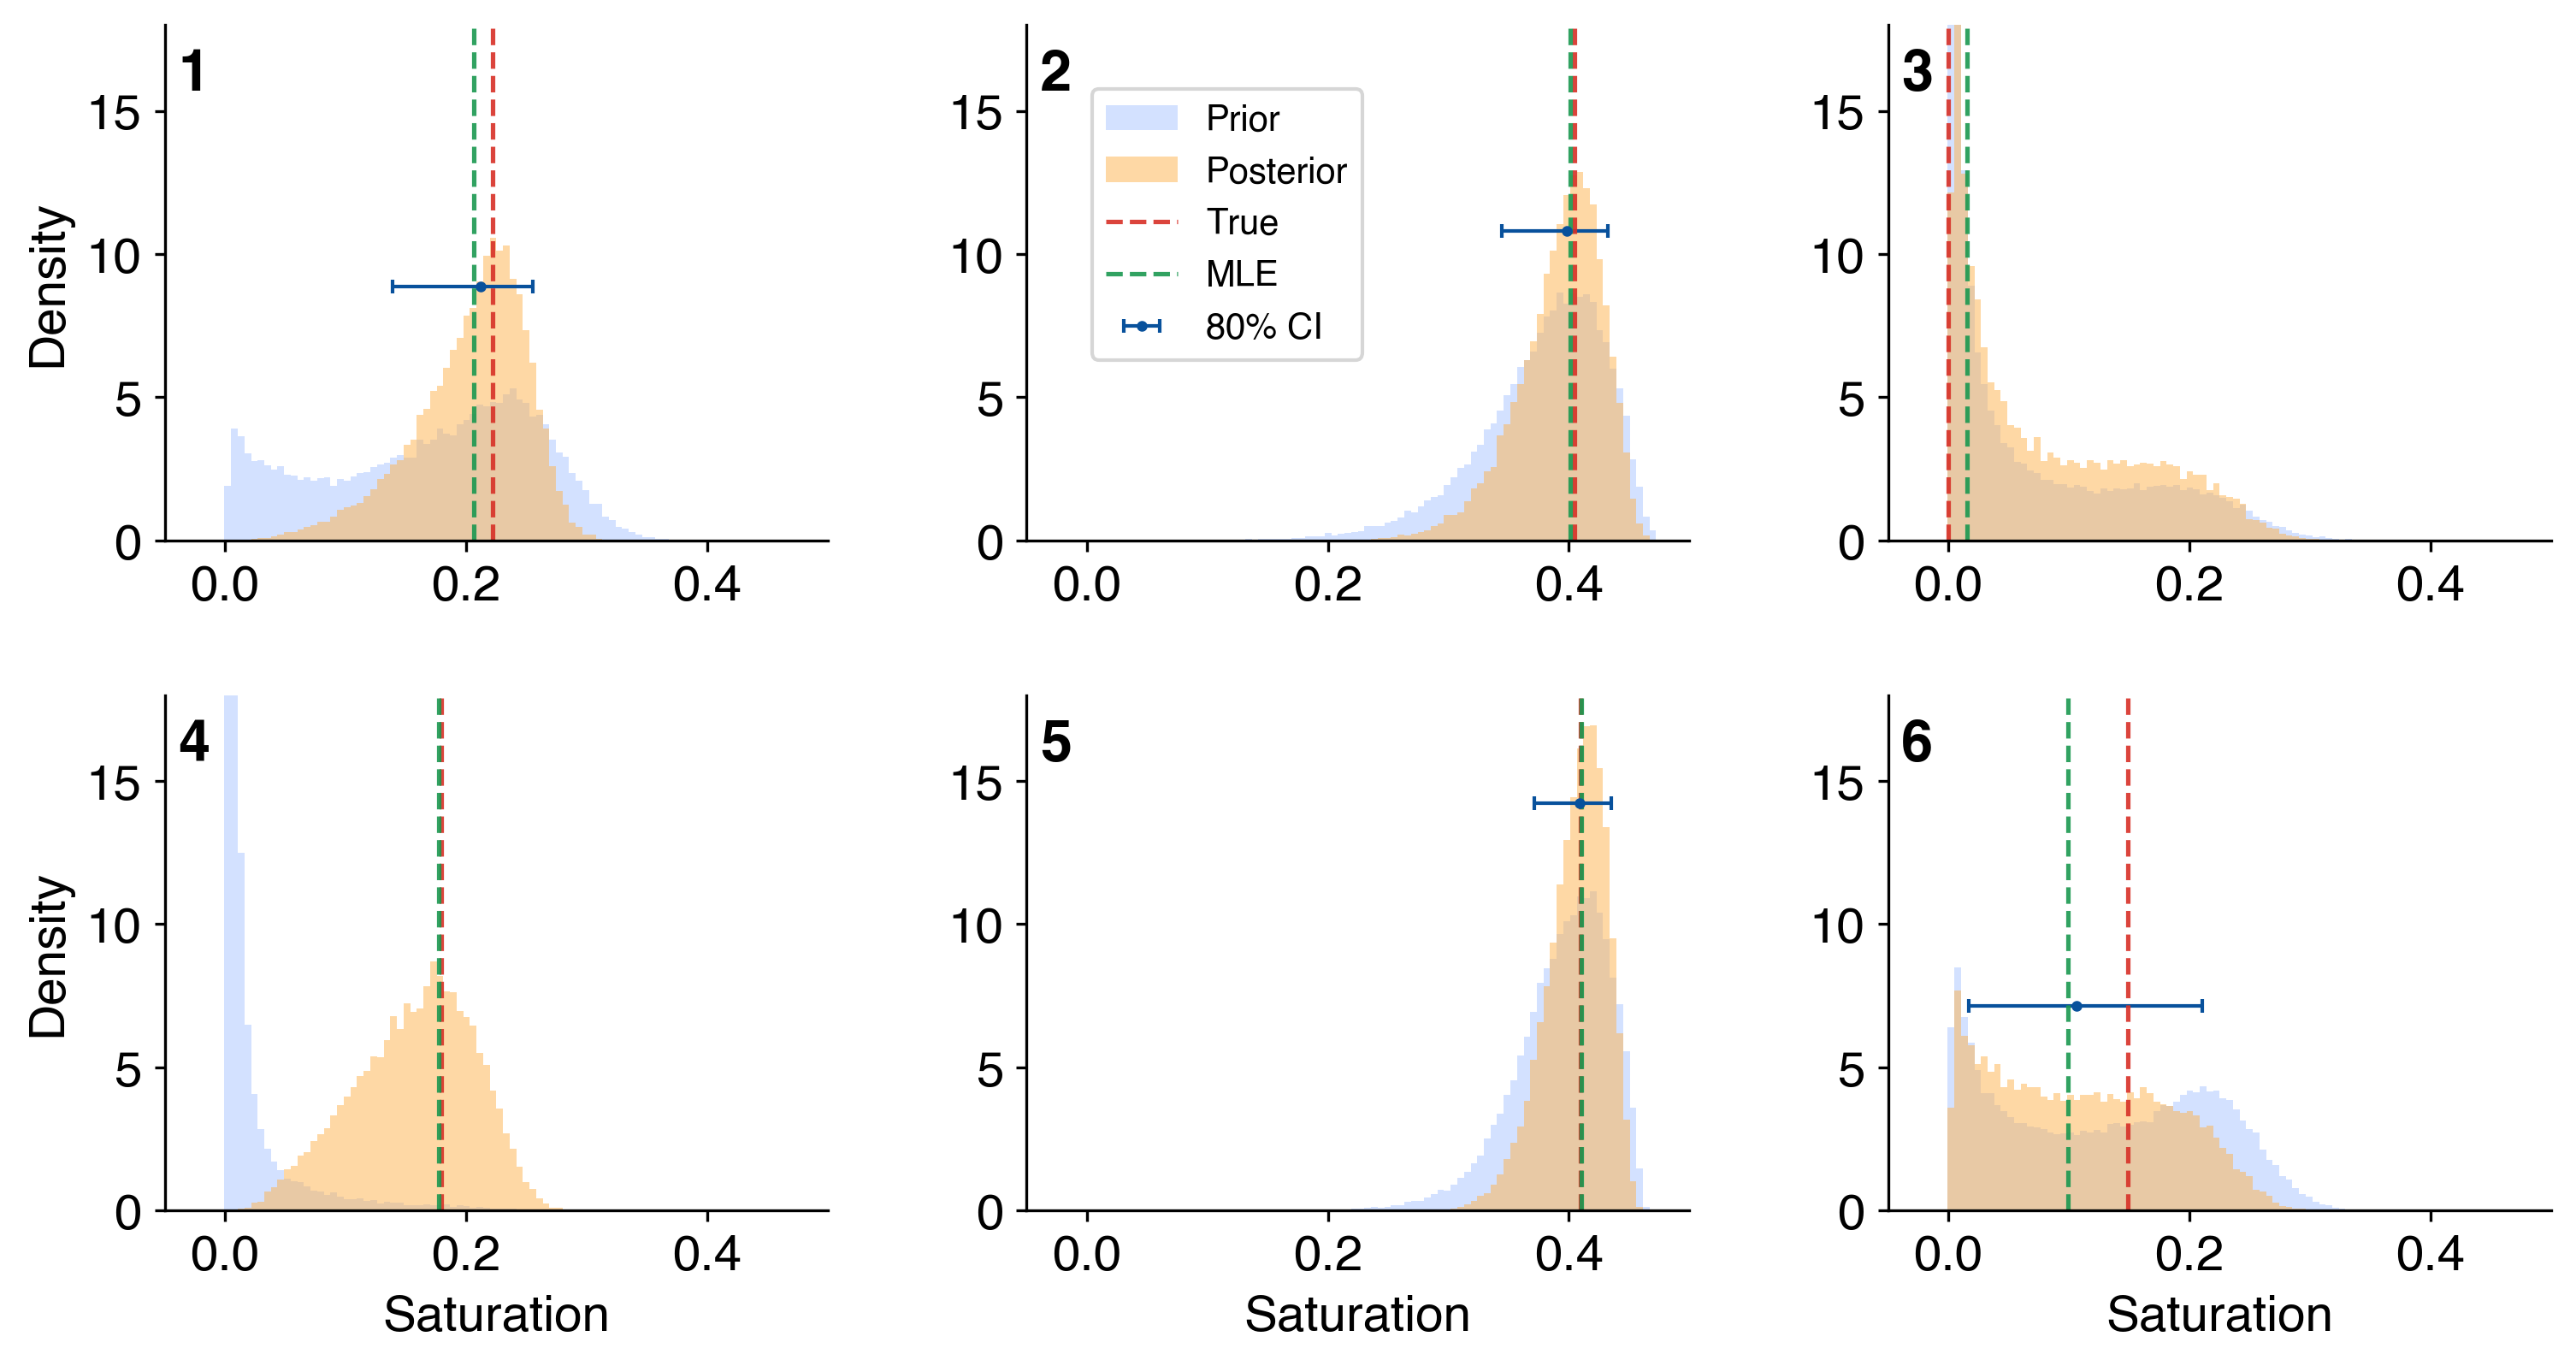

In [67]:
# ---------- Style ----------
fontsize = 14
plt.rcParams.update({
    "font.size": fontsize,
    "axes.labelsize": fontsize,
    "axes.titlesize": fontsize,
    "xtick.labelsize": fontsize,
    "ytick.labelsize": fontsize,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,
})

# Suggested improved colors
prior_fill  = "#a8c5ff"   # neutral light gray
prior_edge  = "#2a5bd7"   # medium gray outline
post_fill   = "#feb24c"   # soft blue fill
post_edge   = "orangered" # dark blue outline
true_color  = "#d73027"   # strong red (stands out)
ci_fill     = "#08519c"   # warm orange band for CI
green_edge  = "#1a9850"   # strong, deep green outline

# Common histogram settings
bins = 100
xlim = (-0.05, 0.5)

# ---------- Figure ----------
fig = plt.figure(figsize=(12, 6), dpi=300)
gs  = gridspec.GridSpec(2, 3, wspace=0.3, hspace=0.3)

# Keep handles for legend
handles, labels = None, None

# Panel labels: a), b), c) ...
panel_labels = ["1", "2", "3", "4", "5", "6"]

for idx, (z_, x_) in enumerate(selected_indices):
    row, col = divmod(idx, 3)
    ax = fig.add_subplot(gs[row, col])

    # Convert to indices (use your current indexing logic)
    ix = int(x_ / dx - 110)
    iz = int(z_ / dz - 260)

    # Samples
    sa_prior_sample     = sa_prior[:, iz, ix]
    sa_posterior_sample = sa_post[:, iz, ix]
    sa_obs_sample       = (sa_obs[iz, ix] + sa_obs[iz, ix+1] + sa_obs[iz, ix-1] + sa_obs[iz+1, ix] + sa_obs[iz-1, ix]) / 5.0
    sa_fwi_sample       = (sa_fwi_inv[iz, ix] + sa_fwi_inv[iz, ix+1] + sa_fwi_inv[iz, ix-1] + sa_fwi_inv[iz+1, ix] + sa_fwi_inv[iz-1, ix]) / 5.0

    # Posterior CI (e.g., central 80%)
    p10, p50, p90 = np.percentile(sa_posterior_sample, [10, 50, 90])

    # --- Histograms (filled + outline for clarity) ---
    n1, b1, _ = ax.hist(sa_prior_sample,     bins=bins, range=xlim, density=True, color=prior_fill, linewidth=0.7, alpha=0.5, label="Prior"     if idx == 0 else None)
    n2, b2, _ = ax.hist(sa_posterior_sample, bins=bins, range=xlim, density=True, color=post_fill,  linewidth=0.7, alpha=0.5, label="Posterior" if idx == 0 else None)

    # # KDE overlays
    # xs = np.linspace(xlim[0], xlim[1], 500)
    # kde_pr  = gaussian_kde(sa_prior_sample)
    # kde_po  = gaussian_kde(sa_posterior_sample)
    # ax.plot(xs, kde_pr(xs), color=prior_edge, linewidth=1.0, alpha=0.5)
    # ax.plot(xs, kde_po(xs), color=post_edge,  linewidth=1.0, alpha=0.5)

    # Posterior 80% CI band
    ax.errorbar(
        p50,                               # x: posterior median
        ax.get_ylim()[1] * 0.80,           # y: place near top of axis
        xerr=[[p50 - p10], [p90 - p50]],   # asymmetric error
        fmt='o', color=ci_fill, ecolor=ci_fill,
        elinewidth=1.0, capsize=2, markersize=2,
        label="80% CI" if idx == 0 else None)

    # True value
    l_true = ax.axvline(sa_obs_sample, color=true_color, linestyle="--", linewidth=1.25, alpha=0.9, label="True" if idx == 0 else None)
    l_fwi  = ax.axvline(sa_fwi_sample, color=green_edge, linestyle="--", linewidth=1.25, alpha=0.9, label="MLE" if idx == 0 else None)
    
    # Panel mini-index in corner
    # ax.text( 0.03, 0.96, f"#{idx+1}",        transform=ax.transAxes, fontsize=12, ha="left", va="top", color="black", fontweight="bold")
    ax.text(0.02, 0.85, panel_labels[idx], transform=ax.transAxes, fontsize=16, ha="left", va="bottom", fontweight="bold")

    # Axis formatting
    ax.set_xlim(xlim)
    ax.set_ylim(bottom=0, top=18)
    ax.tick_params(length=3, width=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if row == 1:
        ax.set_xlabel("Saturation")
    if col == 0:
        ax.set_ylabel("Density")

    if idx == 0:
        handles, labels = ax.get_legend_handles_labels()
        if l_true and "True" not in labels:
            handles.append(l_true)
            labels.append("True")
        
        if l_fwi and "MLE" not in labels:
            handles.append(l_fwi)
            labels.append("MLE")

# Shared legend (clean, outside)
if handles and labels:
    fig.legend(handles, labels, loc="upper center", ncol=1, frameon=True, fontsize=10, bbox_to_anchor=(0.47, 0.85))

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(f"figures_slides/FWI-HMC-Hist-num-{num_samples}-temp-{hmc_temp}-f0-{f0}Hz.png", dpi=300, bbox_inches='tight')
plt.show()

### Clustering the results

In [68]:
# top 10% count
n_top = int(0.1 * len(log_prob))
top_indices = np.argsort(log_prob)[::-1][:n_top]
sa_posterior_top_10 = sa_post[top_indices].reshape(n_top, -1)

In [69]:
# run KMeans on top 10% samples
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
labels = kmeans.fit_predict(sa_posterior_top_10)

# identify medoids (representatives)
medoids = []
for i in range(k):
    cluster_idx = np.where(labels == i)[0]
    cluster_points = sa_posterior_top_10[cluster_idx]
    centroid = kmeans.cluster_centers_[i].reshape(1, -1)
    dists = pairwise_distances(cluster_points, centroid)
    medoid_idx = cluster_idx[np.argmin(dists)]
    medoids.append(medoid_idx)

# representative models (still flattened)
rep_models_flat = sa_posterior_top_10[medoids]

# reshape back to (nz, nx) for interpretation
rep_models = rep_models_flat.reshape(k, nz_sat, nx_sat)

# cluster weights (relative importance of each representative scenario)
cluster_weights = np.bincount(labels) / len(labels)

print("Cluster weights:", cluster_weights)

Cluster weights: [0.24725 0.29725 0.209   0.2465 ]


In [70]:
cluster_weights = [0.25, 0.30, 0.2, 0.25]

/tmp/ipykernel_38673/1433316502.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space at right for colorbar


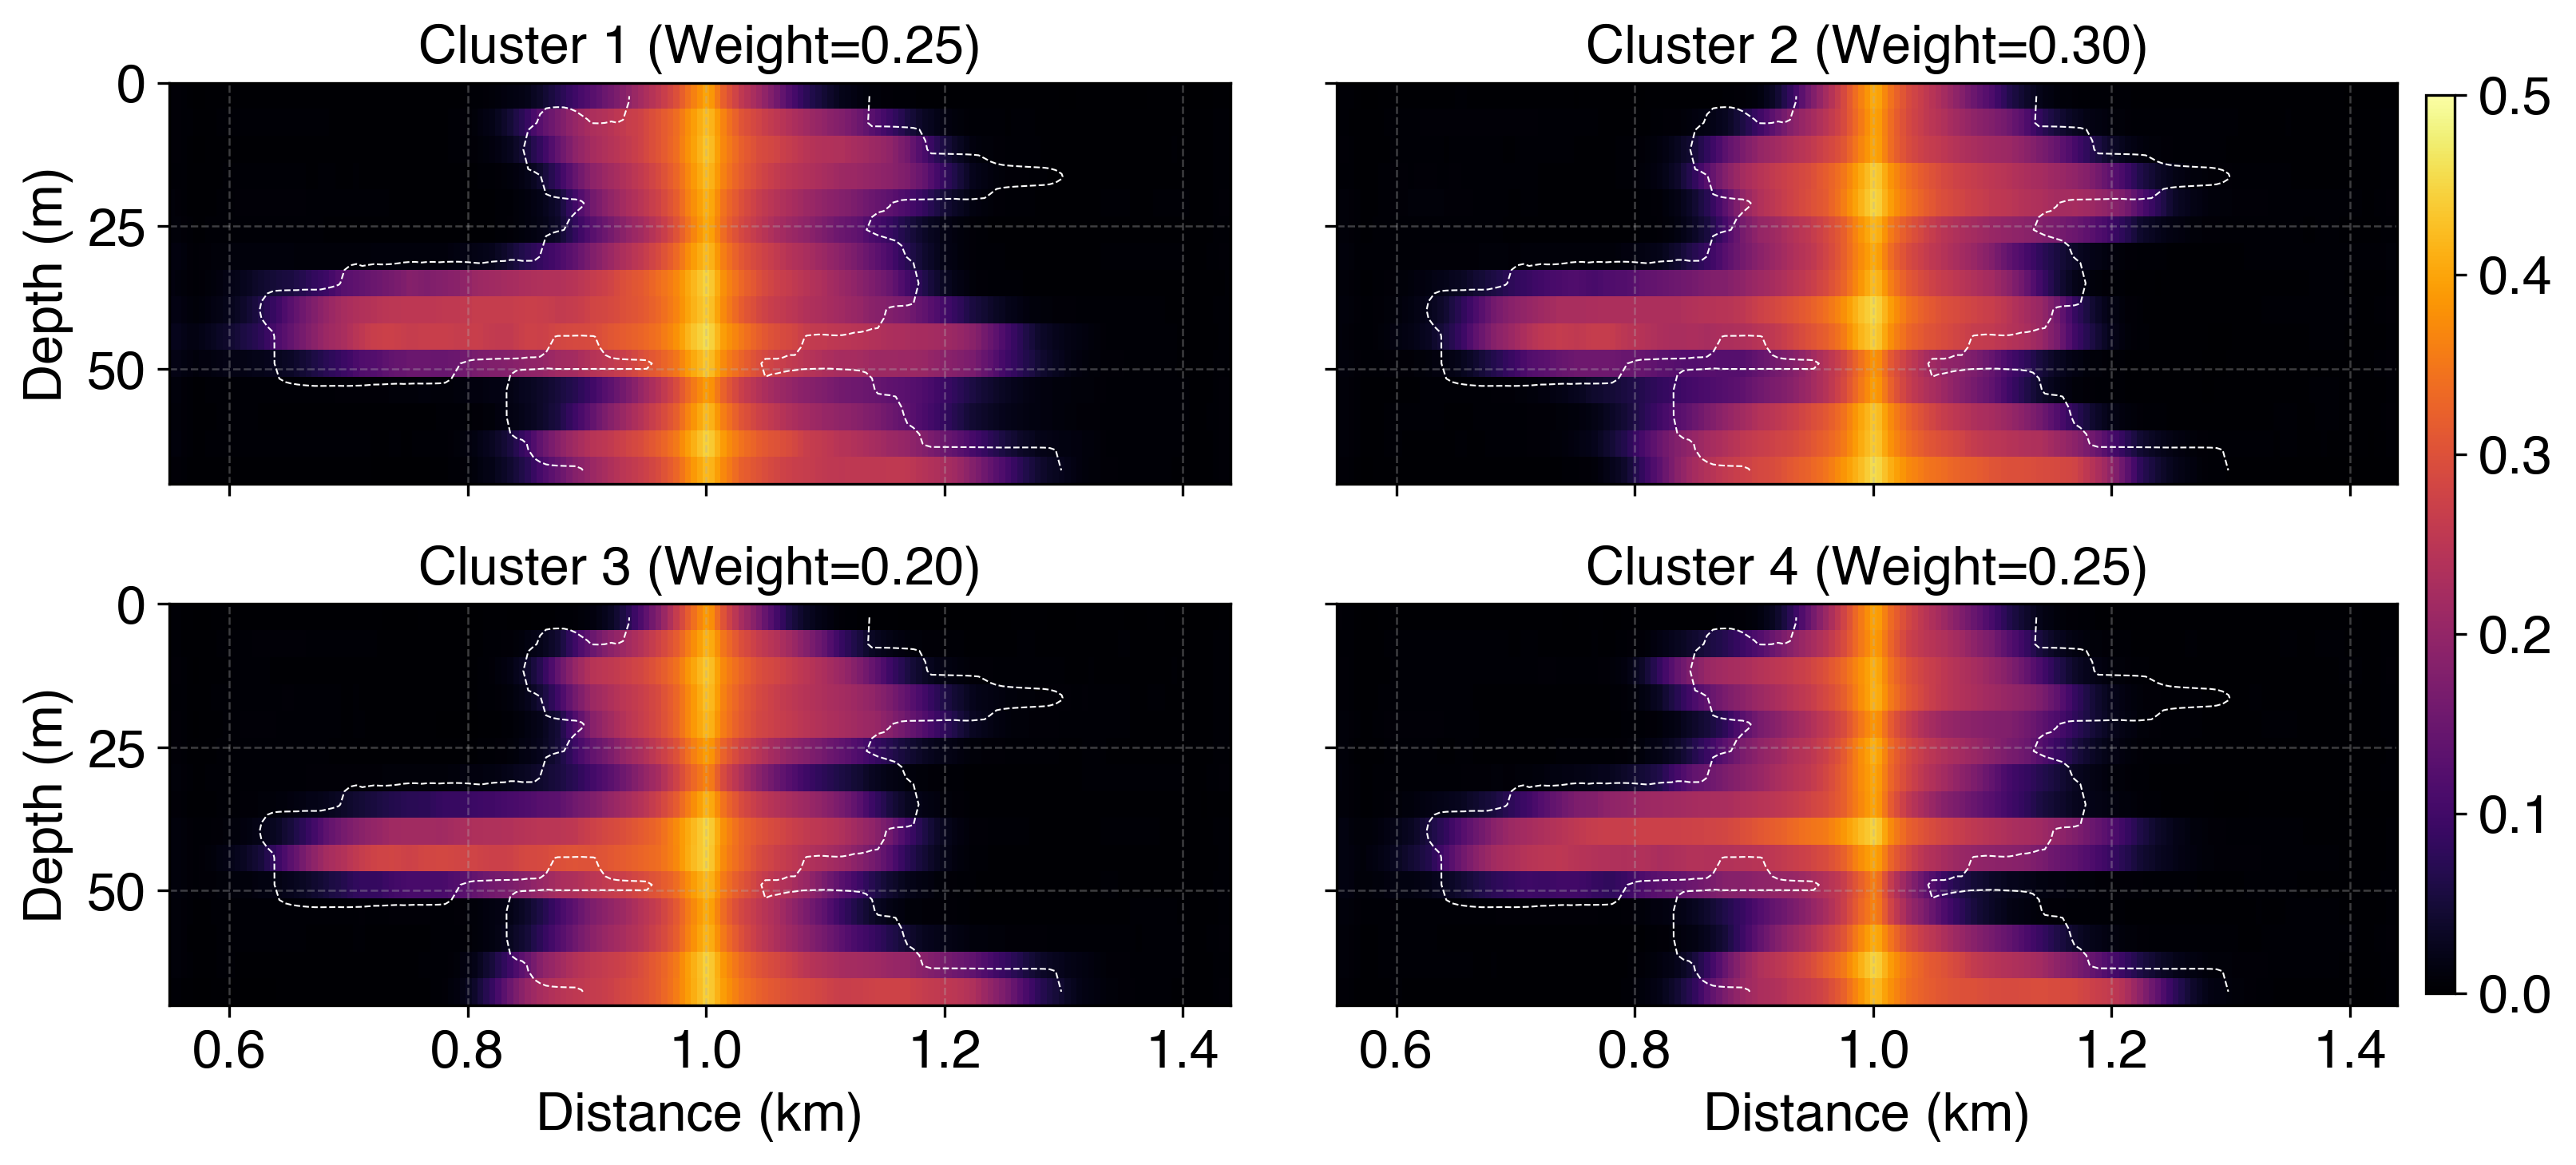

In [71]:
# ---------- Style ----------
fontsize = 16
plt.rcParams.update({
    "font.size": fontsize,
    "axes.labelsize": fontsize,
    "axes.titlesize": fontsize,
    "xtick.labelsize": fontsize,
    "ytick.labelsize": fontsize,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,
})

# ---------- Plot the 4 cluster centroids in 2x2 ----------
nrows, ncols = 2, 2
fig = plt.figure(figsize=(12, 5), dpi=300)  # slightly wider for colorbar
gs = gridspec.GridSpec(nrows, ncols, figure=fig, hspace=0.3, wspace=0.1)
im_axes = []

for i, sa_ in enumerate(rep_models):   # rep_models is (4, nz, nx) from clustering
    row, col = divmod(i, ncols)
    ax = fig.add_subplot(gs[row, col])
    im = ax.imshow(sa_, cmap="inferno", aspect="auto", vmin=0, vmax=0.5, extent=extent_res)
    # ax.text(0.0, 1.05, panel_labels[i], transform=ax.transAxes, fontsize=20, fontweight="bold", ha="left", va="bottom")
    ax.contour(sa_obs, levels=[0.03], extent=extent_res, colors='w', linewidths=0.5, linestyles='dashed', origin='upper')

    # Labels only on bottom row and left col
    if row == nrows - 1:
        ax.set_xlabel("Distance (km)", fontsize=fontsize)
        # ax.set_xticks(np.arange(0.6, res_x[-1]/1000+0.2, 0.2))
        # ax.set_yticks(np.arange(0.80, 0.88, 0.02))
    else:
        ax.set_xticklabels([])

    if col == 0:
        ax.set_ylabel("Depth (m)", fontsize=fontsize)
        # ax.set_yticks(np.arange(res_z[0]/1000, res_z[-1]/1000, 0.02))
    else:
        ax.set_yticklabels([])

    ax.grid(linestyle='--', alpha=0.35, linewidth=0.6)
    ax.set_title(f"Cluster {i+1} (Weight={cluster_weights[i]:.2f})", fontsize=fontsize)
    im_axes.append(im)
    # if i in [0, 2]:
    #     ax.text(-0.13, 1.05, panel_labels[i], transform=ax.transAxes, fontsize=20, ha="left", va="bottom", fontweight="bold")
    # else:
    #     ax.text(-0.07, 1.05, panel_labels[i], transform=ax.transAxes, fontsize=20, ha="left", va="bottom", fontweight="bold")
    

# ---------- Shared colorbar on the right ----------
cbar_ax = fig.add_axes([0.91, 0.12, 0.01, 0.75])  # [left, bottom, width, height]
cbar = fig.colorbar(im_axes[0], cax=cbar_ax, orientation="vertical")
cbar.ax.tick_params(labelsize=fontsize)
cbar.minorticks_off()

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space at right for colorbar
plt.savefig(f"figures_slides/FWI-HMC-Cluster-num-{num_samples}-temp-{hmc_temp}-f0-{f0}Hz.png", dpi=300, bbox_inches="tight")
plt.show()

### Survey Design

In [72]:
fontsize = 15

src_loc = {2: 570, 3: 1000, 4: 1420}
rec_loc = {1: [700], 2: [700, 1300]}

In [73]:
f0 = 30
noise_flag=""

for rec_id_ in [1, 2]:
        fig, axes = plt.subplots(3, 3, figsize=(12, 5), dpi=150, gridspec_kw={'wspace': 0.15, 'hspace': 0.25})
        ims_col0, ims_col1, ims_col2, ims_col3 = [], [], [], []

        for col, src_id_ in enumerate([2, 3, 4]):

            path = Path(f"/net/vision/scr2/haipeng/FWI-HMC/Runs-Paper/SYN-survey-{src_id_}-geophone-{rec_id_}-{f0}Hz{noise_flag}")
            
            # Load data
            latent_posterior_az = az.from_netcdf(path / f"HMC/Posterior-hmc-num-{num_samples}-temp-{hmc_temp}.nc")
            latent_posterior    = latent_posterior_az.posterior['m'].values[0]
            latent_posterior_tensor = torch.as_tensor(latent_posterior, dtype=torch.float32, device=device)
            sa_post, sa_post_mean,  sa_post_std, _,  _,  _ = decode_in_batches(model_vae, latent_posterior_tensor, 512)
        
            # Find MAP sample
            log_prob = np.load(path / f"HMC/LogProb-hmc-num-{num_samples}-temp-{hmc_temp}.npy")
            map_id = np.argmax(log_prob)
            sa_map = sa_post[map_id]      
        
            # FWI results converted to saturation
            # sa_fwi = np.load(path / "Model-FWI-Sat.npy").reshape(15, 179)
            model_fwi = AcousticModel.load(path/"Model-FWI.npz")
            vp_fwi = model_fwi.get_model('vp') - vp_bl
            vp_fwi = vp_fwi[nz0:nz0+nz_res, nx0:nx0+nx_res]
            sa_fwi_inv = rockphysic_inversion(rockphy, vp_fwi, max_iter = 100, verbose=False)

            # ---- MAP ----
            ax1 = axes[0, col]
            im1 = ax1.imshow(sa_map, cmap='inferno', vmin=0, vmax=0.5, aspect='auto', extent=extent_res)
            ax1.contour(sa_obs, levels=[0.03], extent=extent_res, colors='w', linewidths=0.5, linestyles='dashed', origin='upper')
            ax1.set_xticks(np.arange(0.60, 1.5, 0.2))
            ax1.set_yticks([0, 25, 50])
            ax1.tick_params(axis='both', which='major', labelsize=fontsize)
            ax1.grid(linestyle='--', alpha=0.35, linewidth=0.6)
            ims_col1.append(im1)

            # plot the source and receivers
            ax1.scatter(src_loc[src_id_] / 1000, 0.8, marker='*', s=200, color='red', edgecolor='k', linewidths=0.8, zorder=5, label="Source", clip_on=False)
            color='w'
            for rx in rec_loc[rec_id_]:
                ax1.axvline(rx / 1000, linestyle='-', color=color, zorder=4, label="Geophone well" if rx == rec_loc[rec_id_][0] else "")
                color='b'
            # ax1.text(-0.1, 1.19, labels[col], va='center', fontsize=fontsize+4, transform=ax1.transAxes, color='k', fontweight='bold')

            # ---- Posterior mean ----
            ax2 = axes[1, col]
            im2 = ax2.imshow(sa_post_mean, cmap='inferno', vmin=0, vmax=0.5, aspect='auto', extent=extent_res)
            ax2.contour(sa_obs, levels=[0.03], extent=extent_res, colors='w', linewidths=0.5, linestyles='dashed', origin='upper')
            ax2.set_xticks(np.arange(0.60, 1.5, 0.2))
            ax2.set_yticks([0, 25, 50])
            ax2.tick_params(axis='both', which='major', labelsize=fontsize)
            ax2.grid(linestyle='--', alpha=0.35, linewidth=0.6)
            ims_col2.append(im2)

            # ---- Posterior std ----
            ax3 = axes[2, col]
            im3 = ax3.imshow(sa_post_std, cmap='viridis', vmin=0, vmax=0.09, aspect='auto', extent=extent_res)
            ax3.contour(sa_obs, levels=[0.03], extent=extent_res, colors='w', linewidths=0.5, linestyles='dashed', origin='upper')
            ax3.set_xticks(np.arange(0.60, 1.5, 0.2))
            ax3.set_yticks([0, 25, 50])
            ax3.tick_params(axis='both', which='major', labelsize=fontsize)
            ax3.grid(linestyle='--', alpha=0.35, linewidth=0.6)
            ims_col3.append(im3)

            # Labels
            ax3.set_xlabel("Distance (km)", fontsize=fontsize)
            if col == 0:
                ax1.set_ylabel("Depth (m)", fontsize=fontsize)
                ax2.set_ylabel("Depth (m)", fontsize=fontsize)
                ax3.set_ylabel("Depth (m)", fontsize=fontsize)
            
            # close ticks for unnecessary plots
            if col != 0:
                ax1.set_yticklabels([])
                ax2.set_yticklabels([])
                ax3.set_yticklabels([])
                
            ax1.set_xticklabels([])
            ax2.set_xticklabels([])

            # --- Axis labels
            if col == 0:
                for iii, label in enumerate(["MAP", "Posterior Mean", "Posterior SD"]):
                    axes[iii, 0].text(0.02, 0.1, label, va='center', fontsize=fontsize-2, transform=axes[iii, 0].transAxes, color='w', fontweight='bold')
                    
        # ---- Two equal colorbars at the bottom ----
        cax_sat = fig.add_axes([0.15, -0.06, 0.3, 0.02])  # left half
        cax_std = fig.add_axes([0.58, -0.06, 0.3, 0.02])  # right half

        cbar_sat = fig.colorbar(ims_col1[0], cax=cax_sat, orientation='horizontal')
        cbar_sat.ax.tick_params(labelsize=fontsize)
        cbar_sat.set_label("Saturation", fontsize=fontsize)

        cbar_std = fig.colorbar(ims_col3[0], cax=cax_std, orientation='horizontal')
        cbar_std.set_label("Saturation SD", fontsize=fontsize)
        cbar_std.set_ticks([0, 0.03, 0.06, 0.09])
        
        plt.savefig(f"figures_slides/FWI-HMC-Survey-Design-geophone-{rec_id_}-num-{num_samples}-temp-{hmc_temp}-f0-{f0}Hz{noise_flag}.png", dpi=300, bbox_inches='tight')
        plt.close(fig)
        # plt.show()


Decoding batches: 100%|██████████| 79/79 [00:01<00:00, 48.42it/s]


In [74]:
f0 = 30
noise_flag=""

for rec_id_ in [1, 2]:
        fig, axes = plt.subplots(1, 3, figsize=(12, 1.7), dpi=150, gridspec_kw={'wspace': 0.15, 'hspace': 0.25})

        for col, src_id_ in enumerate([2, 3, 4]):

            # ---- MAP ----
            ax1 = axes[col]
            im1 = ax1.imshow(sa_map*0.0, cmap='inferno', vmin=0, vmax=0.5, aspect='auto', extent=extent_res)
            ax1.contour(sa_obs, levels=[0.03], extent=extent_res, colors='w', linewidths=0.5, linestyles='dashed', origin='upper')
            ax1.set_xticks(np.arange(0.60, 1.5, 0.2))
            ax1.set_yticks([0, 25, 50])
            ax1.tick_params(axis='both', which='major', labelsize=fontsize)
            ax1.grid(linestyle='--', alpha=0.35, linewidth=0.6)
            ims_col1.append(im1)

            # plot the source and receivers
            ax1.scatter(src_loc[src_id_] / 1000, 0.8, marker='*', s=200, color='red', edgecolor='k', linewidths=0.8, zorder=5, label="Source", clip_on=False)
            color='w'
            for rx in rec_loc[rec_id_]:
                ax1.axvline(rx / 1000, linestyle='-', color=color, zorder=4, label="Geophone well" if rx == rec_loc[rec_id_][0] else "")
                color='b'
            
            # Labels
            ax1.set_xlabel("Distance (km)", fontsize=fontsize)
            if col ==0:
                ax1.set_ylabel("Depth (m)", fontsize=fontsize)
            
            # close ticks for unnecessary plots
            if col != 0:
                ax1.set_yticklabels([])
     
        plt.savefig(f"figures_slides/FWI-HMC-Survey-Design-geophone-{rec_id_}-num-{num_samples}-temp-{hmc_temp}-f0-{f0}Hz{noise_flag}-new.png", dpi=300, bbox_inches='tight')
        plt.close(fig)
        # plt.show()


### Noise cases

In [75]:
fontsize = 14
device = torch.device(defaults.device)

for src_id_ in [2, 3, 4]:
    for rec_id_ in [1]:
        for f0 in [30]:

            # ---- Setup figure ----
            fig, axes = plt.subplots(3, 3, figsize=(12, 5), dpi=150, gridspec_kw={'wspace': 0.15, 'hspace': 0.25})
            ims_col0, ims_col1, ims_col2, ims_col3 = [], [], [], []

            for col, noise_flag in enumerate(["", "-noise-30dB", "-noise-25dB"]):

                path = Path(f"/net/vision/scr2/haipeng/FWI-HMC/Runs-Paper/SYN-survey-{src_id_}-geophone-{rec_id_}-{f0}Hz{noise_flag}")
                
                # Load data
                latent_posterior_az = az.from_netcdf(path / f"HMC/Posterior-hmc-num-{num_samples}-temp-{hmc_temp}.nc")
                latent_posterior    = latent_posterior_az.posterior['m'].values[0]
                latent_posterior_tensor = torch.as_tensor(latent_posterior, dtype=torch.float32, device=device)
                sa_post, sa_post_mean, sa_post_std, _,  _,  _ = decode_in_batches(model_vae, latent_posterior_tensor, 512)
            
                # Find MAP sample
                log_prob = np.load(path / f"HMC/LogProb-hmc-num-{num_samples}-temp-{hmc_temp}.npy")
                map_id = np.argmax(log_prob)
                sa_map = sa_post[map_id]      

                # FWI results converted to saturation
                # sa_fwi = np.load(path / "Model-FWI-Sat.npy").reshape(15, 179)
                model_fwi = AcousticModel.load(path/"Model-FWI.npz")
                vp_fwi = model_fwi.get_model('vp') - vp_bl
                vp_fwi = vp_fwi[nz0:nz0+nz_res, nx0:nx0+nx_res]
                sa_fwi_inv = rockphysic_inversion(rockphy, vp_fwi, max_iter = 100, verbose=False)

                # --- FWI
                ax0 = axes[0, col]
                im0 = ax0.imshow(sa_fwi_inv, cmap='inferno', vmin=0, vmax=0.5, aspect='auto', extent=extent_res)
                ax0.contour(sa_obs, levels=[0.03], extent=extent_res, colors='w', linewidths=0.5, linestyles='dashed', origin='upper')
                ax0.set_xticks(np.arange(0.60, 1.5, 0.2))
                ax0.grid(linestyle='--', alpha=0.35, linewidth=0.6)
                ims_col0.append(im0)

                # plot the source and receivers
                ax0.scatter(src_loc[src_id_] / 1000, 0.8, marker='*', s=200, color='red', edgecolor='k', linewidths=0.8, zorder=5, label="Source", clip_on=False)
                for rx in rec_loc[rec_id]:
                    ax0.axvline(rx / 1000, linestyle='-', color='w', zorder=4, label="Geophone well" if rx == rec_loc[rec_id][0] else "")

                # # --- MAP
                # ax1 = axes[1, col]
                # im1 = ax1.imshow(sa_map, cmap='inferno', vmin=0, vmax=0.5, aspect='auto', extent=extent_res)
                # ax1.contour(sa_obs, levels=[0.03], extent=extent_res, colors='w', linewidths=0.5, linestyles='dashed', origin='upper')
                # ax1.set_xticks(np.arange(0.60, 1.5, 0.2))
                # ax1.set_yticks([0, 25, 50])
                # ax1.grid(linestyle='--', alpha=0.35, linewidth=0.6)
                # ax1.tick_params(axis='both', which='major', labelsize=fontsize)
                # ims_col1.append(im1)

                # --- Posterior mean
                ax2 = axes[1, col]
                im2 = ax2.imshow(sa_post_mean, cmap='inferno', vmin=0, vmax=0.5, aspect='auto', extent=extent_res)
                ax2.contour(sa_obs, levels=[0.03], extent=extent_res, colors='w', linewidths=0.5, linestyles='dashed', origin='upper')
                ax2.set_xticks(np.arange(0.60, 1.5, 0.2))
                ax2.set_yticks([0, 25, 50])
                ax2.grid(linestyle='--', alpha=0.35, linewidth=0.6)
                ax2.tick_params(axis='both', which='major', labelsize=fontsize)
                ims_col2.append(im2)

                # --- Posterior std
                ax3 = axes[2, col]
                im3 = ax3.imshow(sa_post_std, cmap='viridis', vmin=0, vmax=0.09, aspect='auto', extent=extent_res)
                ax3.contour(sa_obs, levels=[0.03], extent=extent_res, colors='w', linewidths=0.5, linestyles='dashed', origin='upper')
                ax3.set_xticks(np.arange(0.60, 1.5, 0.2))
                ax3.set_yticks([0, 25, 50])
                ax3.grid(linestyle='--', alpha=0.35, linewidth=0.6)
                ax3.tick_params(axis='both', which='major', labelsize=fontsize)
                ims_col3.append(im3)

                # --- Column titles (top row only)
                title = ['Noise Free', 'Noise (SNR 30 dB)', 'Noise (SNR 25 dB)']
                ax0.set_title(f'{title[col]}', fontsize=fontsize-2)

                # Labels
                ax3.set_xlabel("Distance (km)", fontsize=fontsize)
                if col == 0:
                    ax0.set_ylabel("Depth (m)", fontsize=fontsize)
                    ax1.set_ylabel("Depth (m)", fontsize=fontsize)
                    ax2.set_ylabel("Depth (m)", fontsize=fontsize)
                    ax3.set_ylabel("Depth (m)", fontsize=fontsize)
                
                # close ticks for unnecessary plots
                if col != 0:
                    ax0.set_yticklabels([])
                    ax1.set_yticklabels([])
                    ax2.set_yticklabels([])
                    ax3.set_yticklabels([])
                    
                ax0.set_xticklabels([])
                ax1.set_xticklabels([])
                ax2.set_xticklabels([])

                # --- Axis labels
                if col == 0:
                    for iii, label in enumerate(["MLE", "Posterior Mean", "Posterior SD"]):
                        axes[iii, 0].text(0.02, 0.1, label, va='center', fontsize=fontsize-2, transform=axes[iii, 0].transAxes, color='w', fontweight='bold')
                        

            # ---- Two equal colorbars at the bottom (outside loop) ----
            cax_vel = fig.add_axes([0.12, -0.04, 0.35, 0.02])  # left half
            cax_std = fig.add_axes([0.55, -0.04, 0.35, 0.02])  # right half

            cbar_sat = fig.colorbar(ims_col0[0], cax=cax_vel, orientation='horizontal')
            cbar_sat.ax.tick_params(labelsize=fontsize)
            cbar_sat.set_label("Saturation", fontsize=fontsize)
                
            cbar_std = fig.colorbar(ims_col3[0], cax=cax_std, orientation='horizontal')
            cbar_std.ax.tick_params(labelsize=fontsize)
            cbar_std.set_label("Saturation SD", fontsize=fontsize)
            cbar_std.set_ticks([0, 0.03, 0.06, 0.09])
            
            save_path = f"figures_slides/FWI-HMC-Uncertainty-survey-{src_id_}-geophone-{rec_id_}-f0-{f0}-num-{num_samples}-temp-{hmc_temp}.png"
            if save_path:
                plt.savefig(save_path, dpi=300, bbox_inches='tight')
                plt.close(fig)
            else:
                plt.show()

Decoding batches: 100%|██████████| 79/79 [00:01<00:00, 47.73it/s]


In [76]:
fontsize = 12
device = torch.device(defaults.device)

cmap = ListedColormap(["#f0f0f0", "#08519c"])  # Not detectable, Detectable
norm = BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)

for src_id_ in [2, 3, 4]:
    for rec_id_ in [1, 2]:
        for f0 in [30]:

            # ---- Setup figure ----
            fig, axes = plt.subplots(1, 3, figsize=(12, 2), dpi=150, gridspec_kw={'wspace': 0.15, 'hspace': 0.25})
            ims_col0, ims_col1, ims_col2, ims_col3 = [], [], [], []

            for col, noise_flag in enumerate(["", "-noise-30dB", "-noise-25dB"]):

                path = Path(f"/net/vision/scr2/haipeng/FWI-HMC/Runs-Paper/SYN-survey-{src_id_}-geophone-{rec_id_}-{f0}Hz{noise_flag}")
                
                # Load data
                latent_posterior_az = az.from_netcdf(path / f"HMC/Posterior-hmc-num-{num_samples}-temp-{hmc_temp}.nc")
                latent_posterior    = latent_posterior_az.posterior['m'].values[0]
                latent_posterior_tensor = torch.as_tensor(latent_posterior, dtype=torch.float32, device=device)
                sa_post, sa_post_mean, sa_post_std, _,  _,  _ = decode_in_batches(model_vae, latent_posterior_tensor, 512)
            
            
                # Binary detectability map
                detectable = sa_post_std < 0.08
                ax = axes[col]
            
                im = ax.imshow(detectable.astype(int), cmap=cmap, norm=norm, aspect="auto", extent=extent_res, origin="upper")
         
                # Observed plume contour
                ax.contour(sa_obs, levels=[0.03], extent=extent_res, colors="k", linewidths=0.6, linestyles="dashed", origin="upper")

                # plot the source and receivers
                ax.scatter(src_loc[src_id_] / 1000, 0.8, marker='*', s=200, color='red', edgecolor='k', linewidths=0.8, zorder=15, label="Source", clip_on=False)
                color='w'
                for rx in rec_loc[rec_id_]:
                    ax1.axvline(rx / 1000, linestyle='-', color=color, zorder=16, label="Geophone well" if rx == rec_loc[rec_id_][0] else "")
                    color='b'
                
                ax.set_title(titles[col], fontsize=fontsize)
                ax.set_xlabel("Distance (km)", fontsize=fontsize)

                if col == 0:
                    ax.set_ylabel("Depth (m)", fontsize=fontsize)

                ax.set_xticks(np.arange(0.60, 1.5, 0.2))
                ax.tick_params(labelsize=fontsize)
                ax.grid(linestyle="--", alpha=0.35, linewidth=0.6)

            # Common colorbar
            cbar = fig.colorbar(im, ax=axes, ticks=[0, 1], fraction=0.035, pad=0.02)
            cbar.ax.set_yticklabels(["N", "Y"])
            cbar.ax.tick_params(labelsize=fontsize - 2)

            save_path = f"figures_slides/FWI-HMC-Uncertainty-survey-{src_id_}-geophone-{rec_id_}-f0-{f0}-num-{num_samples}-temp-{hmc_temp}-mask.png"
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            plt.close(fig)
            # plt.show()

Decoding batches: 100%|██████████| 79/79 [00:01<00:00, 49.03it/s]


### Baseline Error